In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Dynamic GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1790921006.548905   28254 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790921006.943628   28254 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790921009.081292   28254 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dynamic GPU memory growth enabled.


W0000 00:00:1790921015.186445   28254 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [ ]:
# %% [markdown]
# ## 1. Setup & Configuration

# %%
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks

# Configuration Constants
DATA_DIR = 'data/raw/strawberry_color'
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
# %% [markdown]
# ## 2. Load and Split Dataset

# %%
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

# Carve out a test set from validation
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

Found 3171 files belonging to 4 classes.
Using 2537 files for training.


W0000 00:00:1790921023.131081   28254 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790921023.477730   28254 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5198 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 3171 files belonging to 4 classes.
Using 634 files for validation.
Detected 4 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


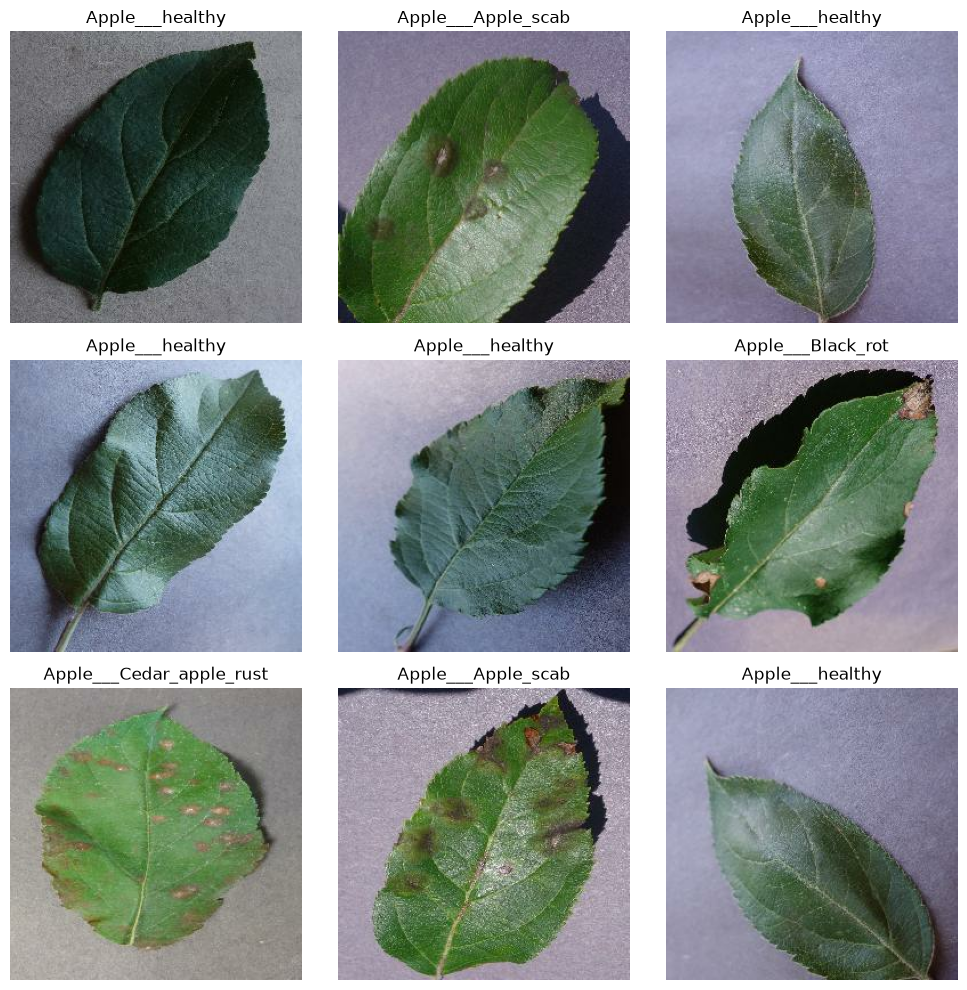

In [4]:
# %% [markdown]
# ## 3. Data Sanity Check

# %%
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# %% [markdown]
# ## 4. Pipeline Optimization

# %%
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
# %% [markdown]
# ## 5. Model Architecture

# %%
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Preprocessing & Data Augmentation
    layers.Rescaling(1.0 / 255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),

    # Feature Extractor
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# %% [markdown]
# ## 6. Training

# %%
os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)

training_callbacks = [
    callbacks.TensorBoard(log_dir='logs'),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,               # Give it 10 epochs before giving up
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1                  # Logs when the learning rate drops
    )
]

history = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=training_callbacks
)

Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.7623 - loss: 0.6324 - val_accuracy: 0.1051 - val_loss: 1.4522 - learning_rate: 3.0000e-04
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8904 - loss: 0.3243 - val_accuracy: 0.1210 - val_loss: 1.4121 - learning_rate: 3.0000e-04
Epoch 3/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.9184 - loss: 0.2400 - val_accuracy: 0.6115 - val_loss: 1.5597 - learning_rate: 3.0000e-04
Epoch 4/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9397 - loss: 0.2039 - val_accuracy: 0.5573 - val_loss: 2.2079 - learning_rate: 3.0000e-04
Epoch 5/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9373 - loss: 0.1770
Epoch 5: ReduceLROnPlateau reducing learning rate to 6.000000284984708e-05.
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9373 - loss: 0.1770 - val_accuracy: 0.6083 - val_loss: 1.5883 - learning_rate: 3.0000e-04
Epoch 6/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9464

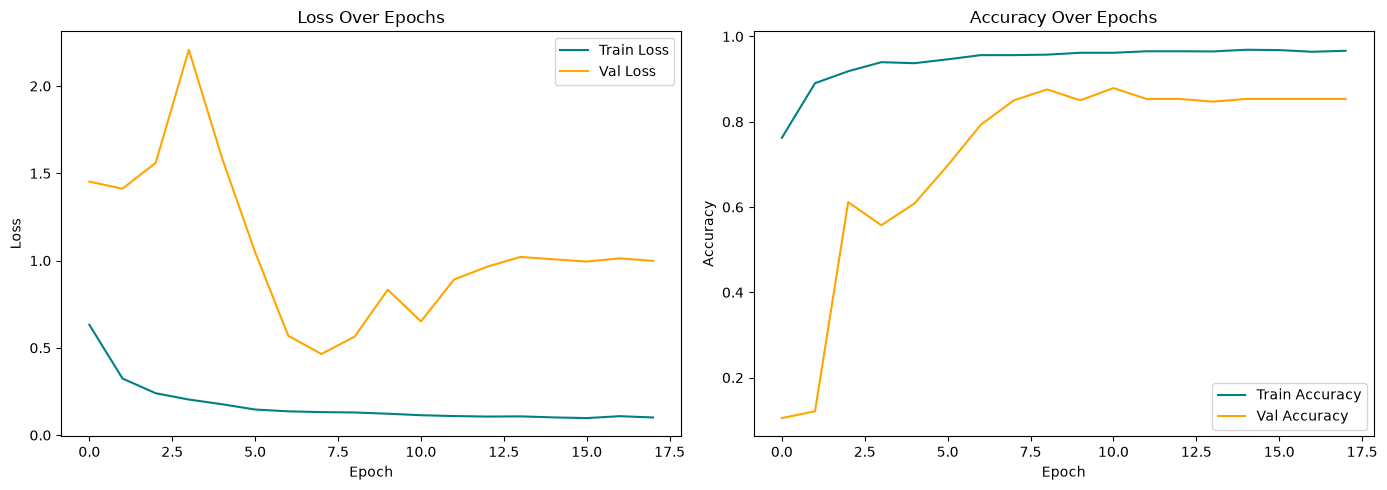

In [11]:
# %% [markdown]
# ## 7. Training Visualizations

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Train Loss', color='teal')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
# %% [markdown]
# ## 8. Test Set Evaluation & Export

# %%
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8406 - loss: 0.4641

Final Test Loss: 0.4641
Final Test Accuracy: 84.06%


In [ ]:
model_path = os.path.join('models', 'strawberry_classifier.keras')
model.save(model_path)
print(f"Model saved to {model_path}")

Model saved to models/apple_leaf_classifier.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Condition: Apple___Cedar_apple_rust (99.68% confidence)


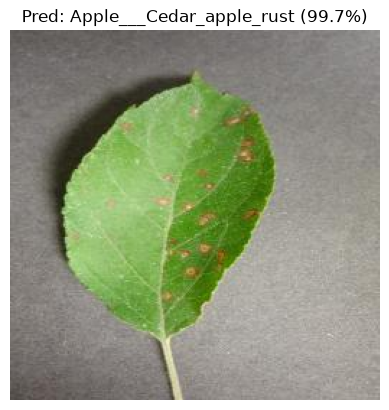

In [15]:
# %% [markdown]
# ## 9. Single Image Inference

# %%
loaded_model = tf.keras.models.load_model(model_path)

import random

random_class = random.choice(class_names)


# Pick an arbitrary sample leaf
sample_image_path = os.path.join(DATA_DIR, random_class, random.choice(os.listdir(os.path.join(DATA_DIR, random_class))))

# Read and format
img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resized_img = cv2.resize(img, IMG_SIZE)
input_tensor = np.expand_dims(resized_img, axis=0)

# Predict
predictions = loaded_model.predict(input_tensor)
predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

print(f"Predicted Condition: {predicted_class} ({confidence:.2f}% confidence)")

# Display image with predicted label
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.1f}%)")
plt.axis("off")
plt.show()